In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

In [2]:
df = pd.read_pickle(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Pickle files\DataPrep_MC1.pkl")
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,tenure_years
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,4,7,0,0,0,0,0,0,1,1.815
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,2,5,0,0,0,0,0,0,0,0.309
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,10,4,0,0,0,0,0,0,0,0.854
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,4,6,0,0,0,0,0,0,0,0.381
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,6,5,0,0,0,0,0,0,0,0.441


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   string 
 2   Marital_Status       2240 non-null   string 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   MntWines             2240 non-null   int64  
 8   MntFruits            2240 non-null   int64  
 9   MntMeatProducts      2240 non-null   int64  
 10  MntFishProducts      2240 non-null   int64  
 11  MntSweetProducts     2240 non-null   int64  
 12  MntGoldProds         2240 non-null   int64  
 13  NumDealsPurchases    2240 non-null   int64  
 14  NumWebPurchases      2240 non-null   int64  
 15  NumCatalogPurchases  2240 non-null   i

#### Data Protocol

In [5]:
warnings.simplefilter(action='ignore', category=FutureWarning) 

# Type of values
df.dtypes.to_excel(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Data Protocol\MC1_datatype.xlsx", sheet_name='data_type')

# Maximum values
df.max().to_excel(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Data Protocol\max_MC1.xlsx", sheet_name='max')

# Minimum values
df.min().to_excel(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Data Protocol\min_MC1.xlsx", sheet_name='min')

# Missing values
df.isnull().sum(axis=0).to_excel(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Data Protocol\NA_MC1.xlsx", sheet_name='NA')

# Unique values
df.nunique().to_excel(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Data Protocol\unique_MC1.xlsx", sheet_name='unique')


#### Data Visualization

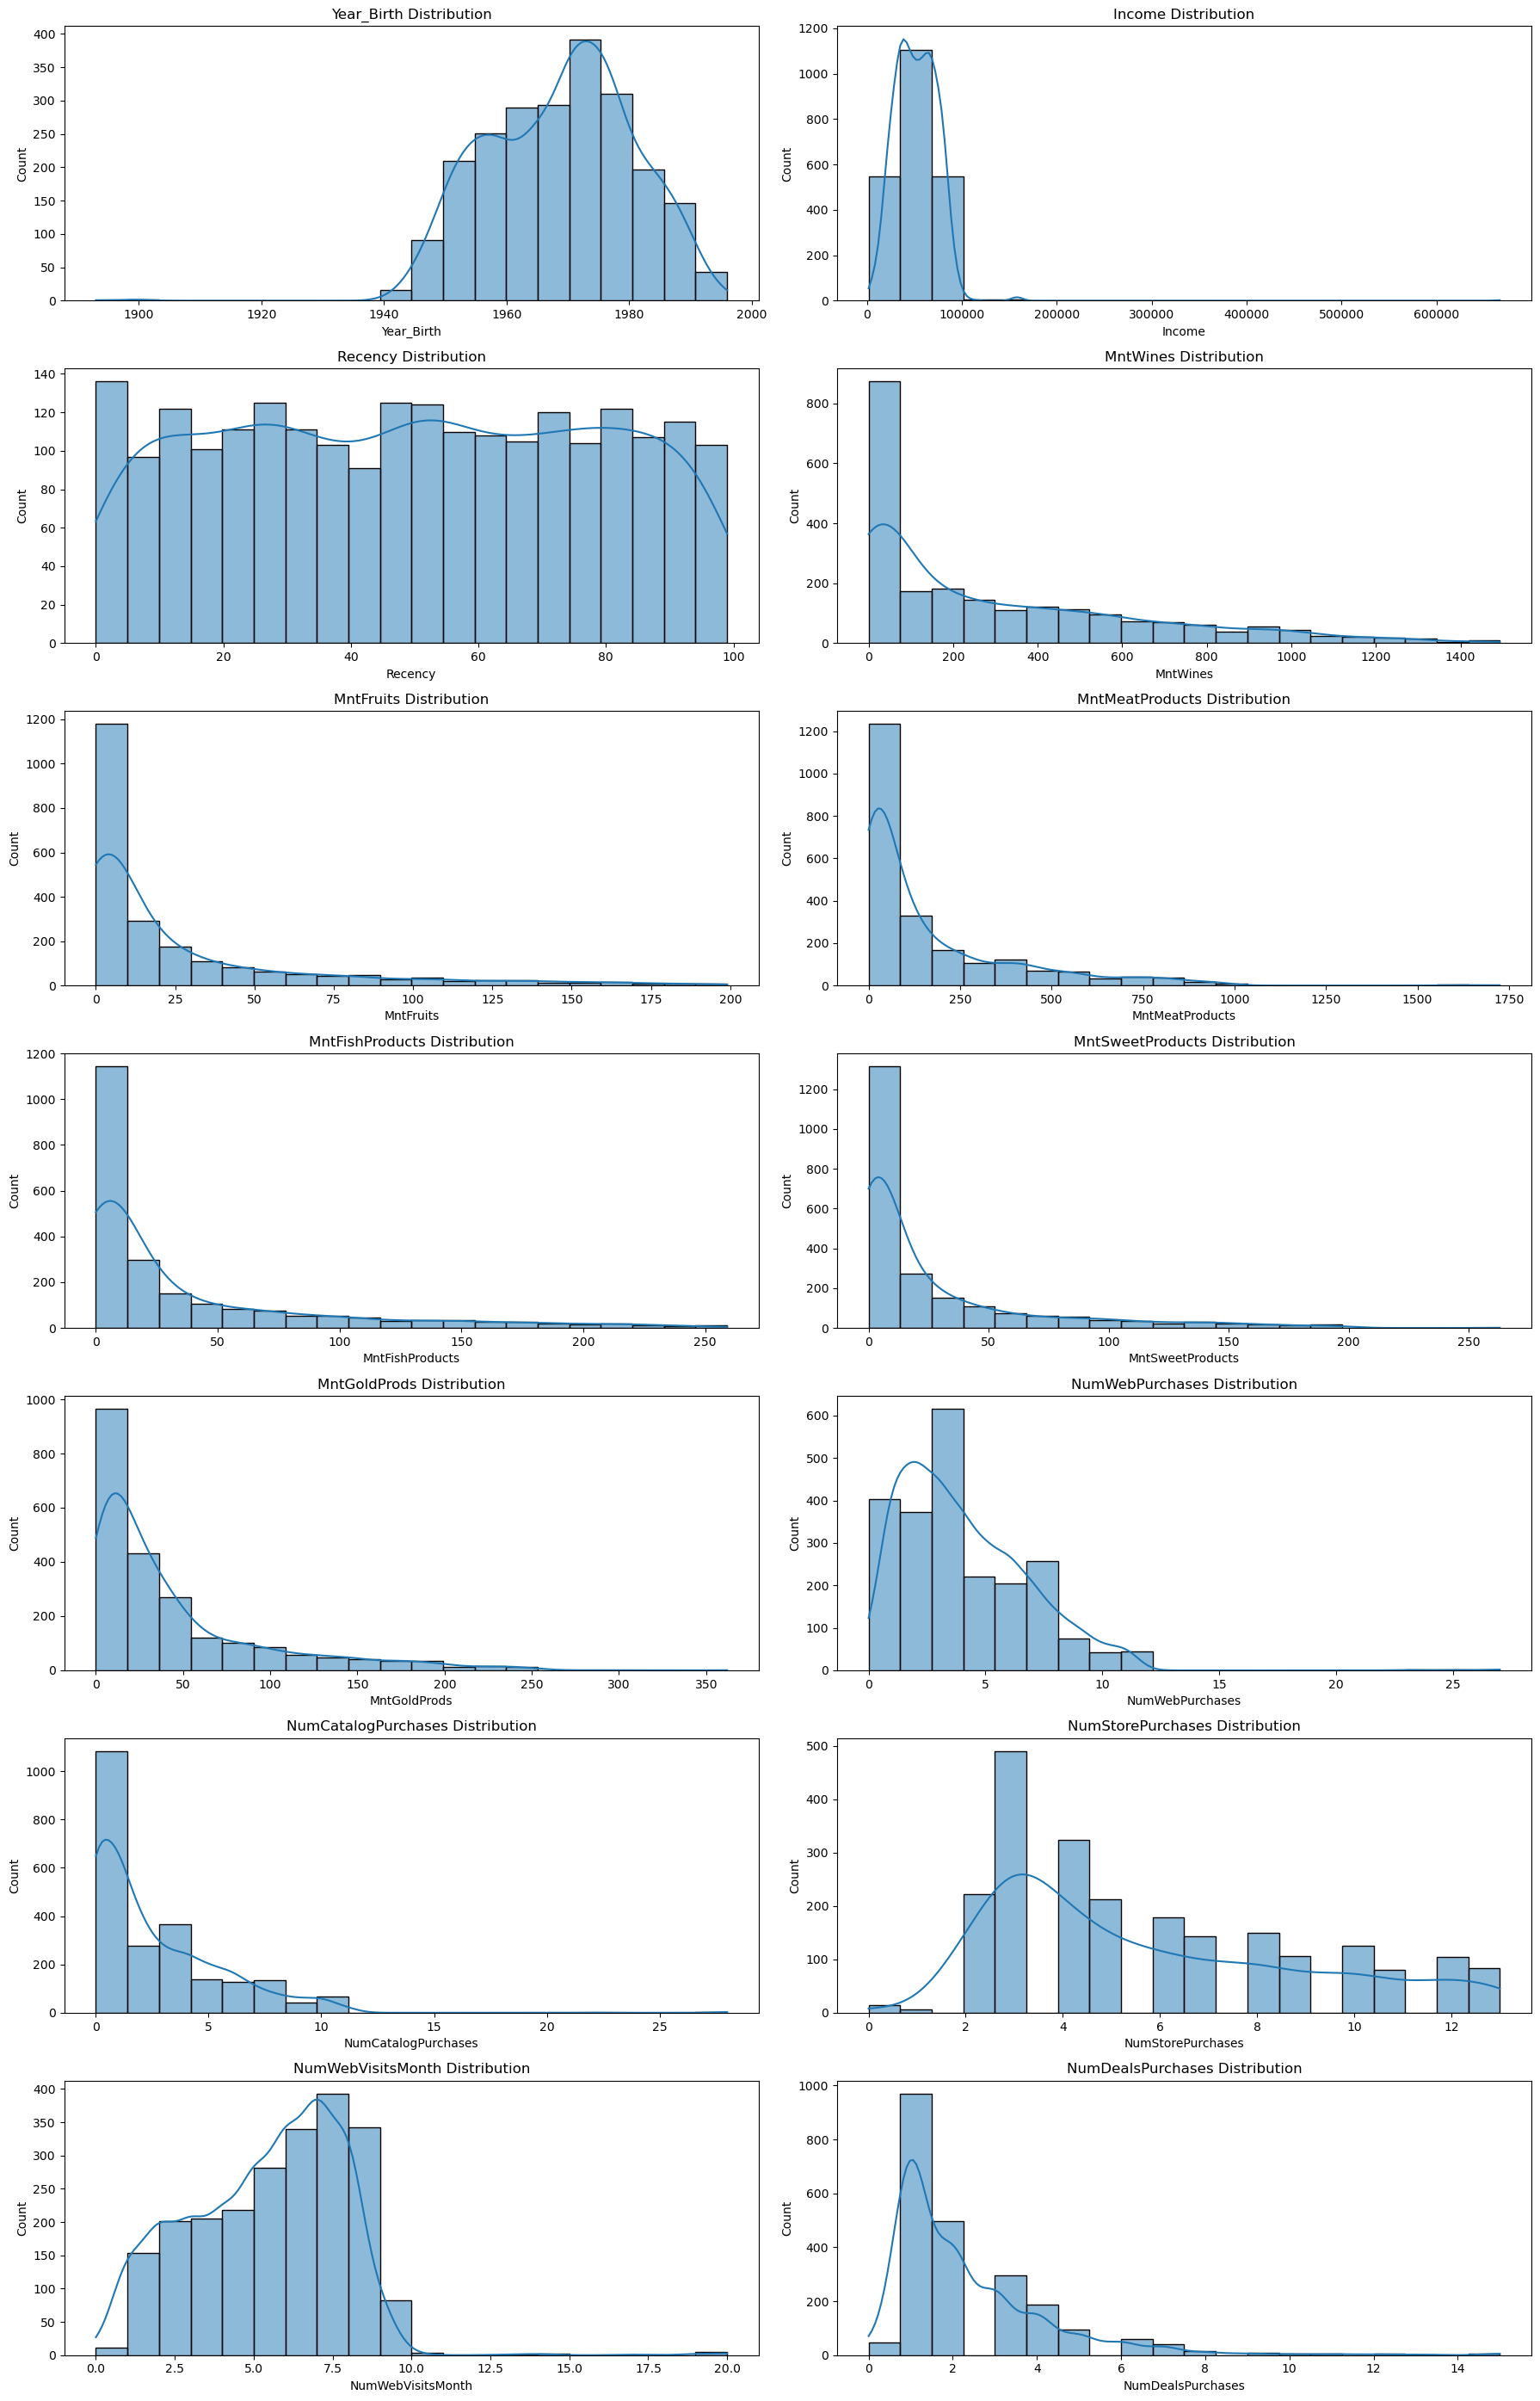

In [7]:
#Numeric Columns
num_cols = df[['Year_Birth','Income','Recency','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts',
               'MntGoldProds','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth','NumDealsPurchases']]

n = len(num_cols)
cols = 2
rows = 7

plt.figure(figsize=(cols * 9, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(data=df, x=col, kde=True, bins=20)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

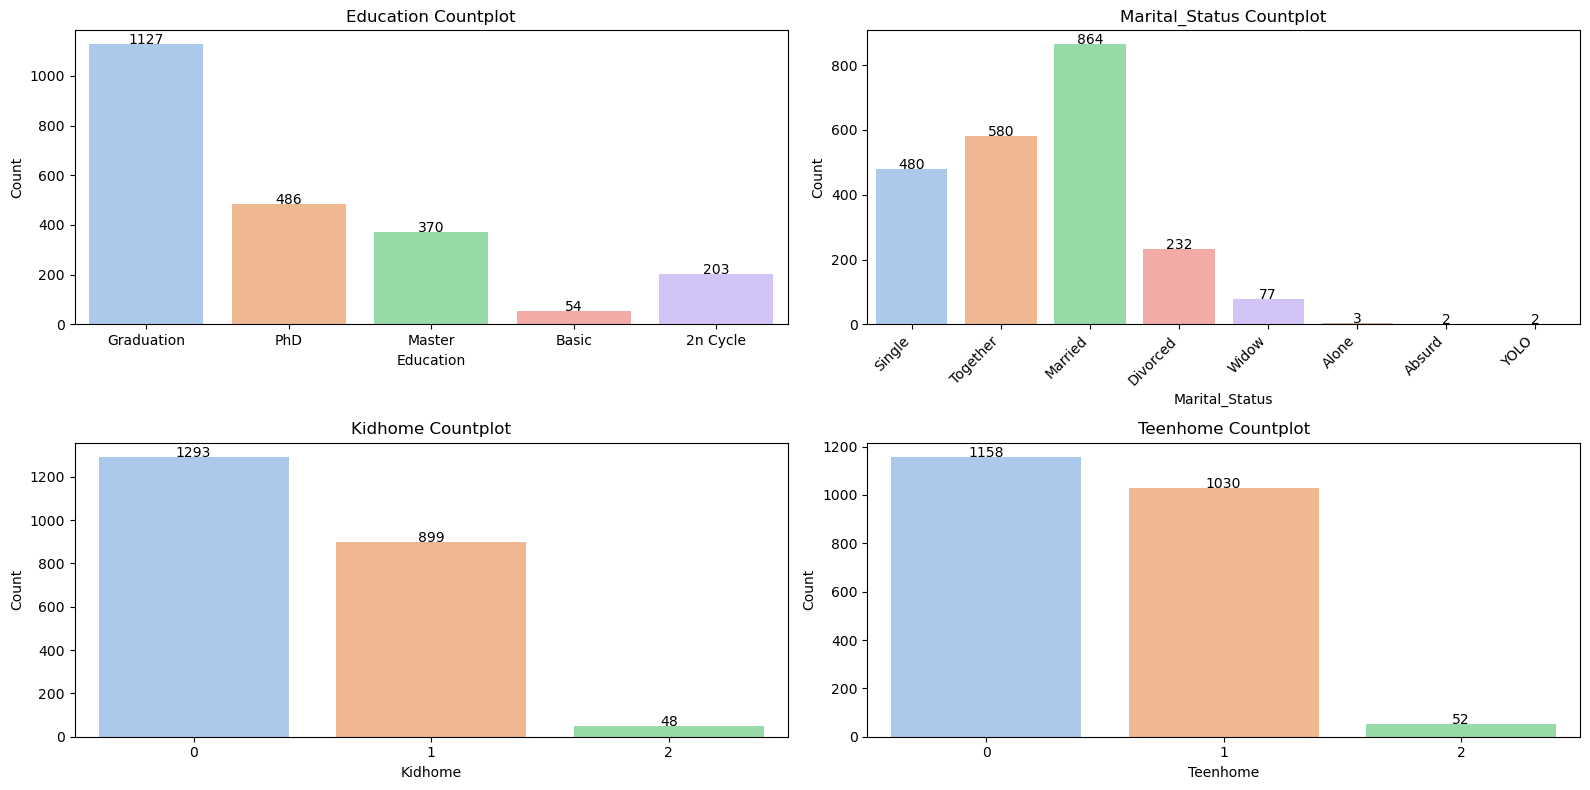

In [8]:
# Categorial Columns
cat_cols = df[['Education','Marital_Status','Kidhome','Teenhome']]

def plot_categorical_countplots(df, cat_cols, cols=2, figsize_per_plot=(8, 4)):
    n = len(cat_cols)
    if n == 0:
        print("No categorical columns to plot.")
        return

    rows = 2
    plt.figure(figsize=(cols * figsize_per_plot[0], rows * figsize_per_plot[1]))

    for i, col in enumerate(cat_cols):
        ax = plt.subplot(rows, cols, i + 1)

        # Handle missing or all-null columns gracefully
        if df[col].dropna().nunique() == 0:
            ax.set_title(f"{col} (Empty)")
            continue

        sns.countplot(data=df, x=col, palette='pastel', ax=ax)

        ax.set_title(f'{col} Countplot')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

        # Add counts on bars
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width()/2., height + 0.1, int(height), ha='center')

        # Rotate x-labels if too many categories
        if df[col].nunique() > 5:
            labels = ax.get_xticklabels()
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha='right')


    plt.tight_layout()
    plt.show()

plot_categorical_countplots(df, cat_cols)

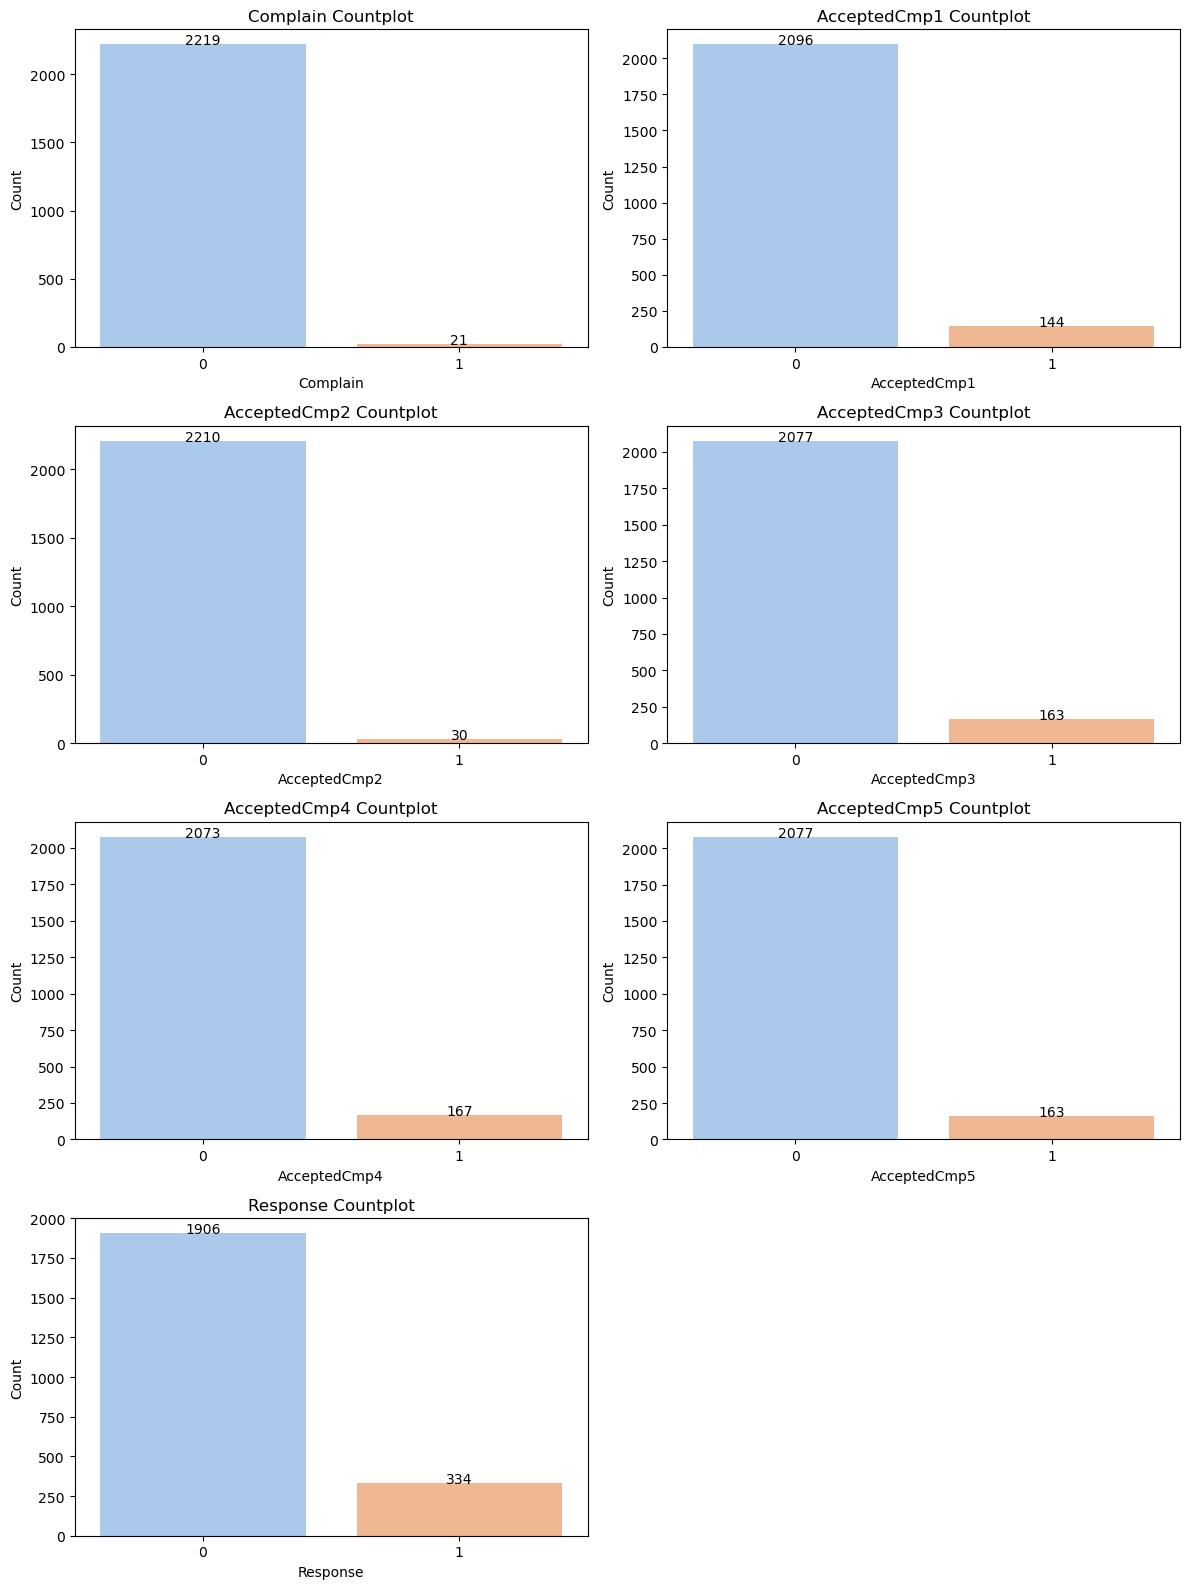

In [9]:
# Categorial - Dummy Columns
dum_cols = df[['Complain','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]

def plot_dummy_countplots(df, dum_cols, cols=2, figsize_per_plot=(6, 4)):
    n = len(dum_cols)
    if n == 0:
        print("No dummy columns to plot.")
        return

    rows = 4
    plt.figure(figsize=(cols * figsize_per_plot[0], rows * figsize_per_plot[1]))

    for i, col in enumerate(dum_cols):
        ax = plt.subplot(rows, cols, i + 1)

        # Handle missing or all-null columns gracefully
        if df[col].dropna().nunique() == 0:
            ax.set_title(f"{col} (Empty)")
            continue

        sns.countplot(data=df, x=col, palette='pastel', ax=ax)

        ax.set_title(f'{col} Countplot')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

        # Add counts on bars
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width()/2., height + 0.1, int(height), ha='center')

        # For dummy vars, usually just two categories, no rotation needed
        # But if you want, can add rotation if categories > 2

    plt.tight_layout()
    plt.show()
plot_dummy_countplots(df,dum_cols)   

#### Skewness

In [11]:
from scipy.stats import skew

# Initialize counters
normal_count = 0
non_normal_count = 0

print("Skewness Analysis:\n")

for column in num_cols:
    col_data = df[column].dropna()
    if col_data.empty:
        print(f'{column}: Skewness not applicable (only NaN values)')
        continue

    skewness = skew(col_data)
    if -0.5 <= skewness <= 0.5:
        print(f'{column} - Skewness: {skewness:.2f} => Approximately normal')
        normal_count += 1
    elif -1 <- skewness <= 1:
        print(f'{column} - Skewness: {skewness:.2f} => Moderately skewed')
        non_normal_count += 1
    else:
        print(f'{column} - Skewness: {skewness:.2f} => Highly skewed')
        non_normal_count += 1

print("\nSummary:")
print(f'Total Normal Features: {normal_count}')
print(f'Total Non-Normal Features: {non_normal_count}')

Skewness Analysis:

Year_Birth - Skewness: -0.35 => Approximately normal
Income - Skewness: 6.76 => Highly skewed
Recency - Skewness: -0.00 => Approximately normal
MntWines - Skewness: 1.17 => Highly skewed
MntFruits - Skewness: 2.10 => Highly skewed
MntMeatProducts - Skewness: 2.08 => Highly skewed
MntFishProducts - Skewness: 1.92 => Highly skewed
MntSweetProducts - Skewness: 2.13 => Highly skewed
MntGoldProds - Skewness: 1.88 => Highly skewed
NumWebPurchases - Skewness: 1.38 => Highly skewed
NumCatalogPurchases - Skewness: 1.88 => Highly skewed
NumStorePurchases - Skewness: 0.70 => Moderately skewed
NumWebVisitsMonth - Skewness: 0.21 => Approximately normal
NumDealsPurchases - Skewness: 2.42 => Highly skewed

Summary:
Total Normal Features: 3
Total Non-Normal Features: 11


**Skewness & Distribution Insights**

- Most behavioral and monetary features are **right-skewed**, reflecting a small group of highly active / high-spending customers.
- `Income` shows **extreme skewness**, indicating strong outliers and a heavy-tailed distribution.
- A small subset of features (`Year_Birth`, `Recency`, `NumWebVisitsMonth`) are approximately normally distributed.
- Skewness is consistent across related feature groups (spending, purchases, promotions), suggesting structural customer heterogeneity rather than data quality issues.


#### Scale & Distance Awareness

In [14]:
# -----------------------------
# Scale & Distance Awareness
# -----------------------------

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

scale_summary = pd.DataFrame({
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'range': df[numeric_cols].max() - df[numeric_cols].min(),
    'std': df[numeric_cols].std()
})

scale_summary = (
    scale_summary
    .sort_values('range', ascending=False)
)

scale_summary

,min,max,range,std
Income,1730.0,666666.000,664936.000,25173.076661
MntMeatProducts,0.0,1725.000,1725.000,225.715373
MntWines,0.0,1493.000,1493.000,336.597393
MntGoldProds,0.0,362.000,362.000,52.167439
MntSweetProducts,0.0,263.000,263.000,41.280498
MntFishProducts,0.0,259.000,259.000,54.628979
MntFruits,0.0,199.000,199.000,39.773434
Year_Birth,1893.0,1996.000,103.000,11.984069
Recency,0.0,99.000,99.000,28.962453
NumCatalogPurchases,0.0,28.000,28.000,2.923101


**Scale & Distance Awareness**

Because K-Means clustering relies on distance calculations, feature scale was examined to identify variables that could disproportionately influence cluster formation. The analysis revealed substantial differences in feature ranges, with `Income` exhibiting a dramatically larger scale than all other variables, followed by several spending-related features. In contrast, campaign response indicators and household composition variables operated within very small numerical ranges. These findings indicated that unscaled data would cause clustering behavior to be dominated by a small subset of large-scale variables, providing strong justification for applying feature scaling prior to model training.


#### Spearman's Correlation test:

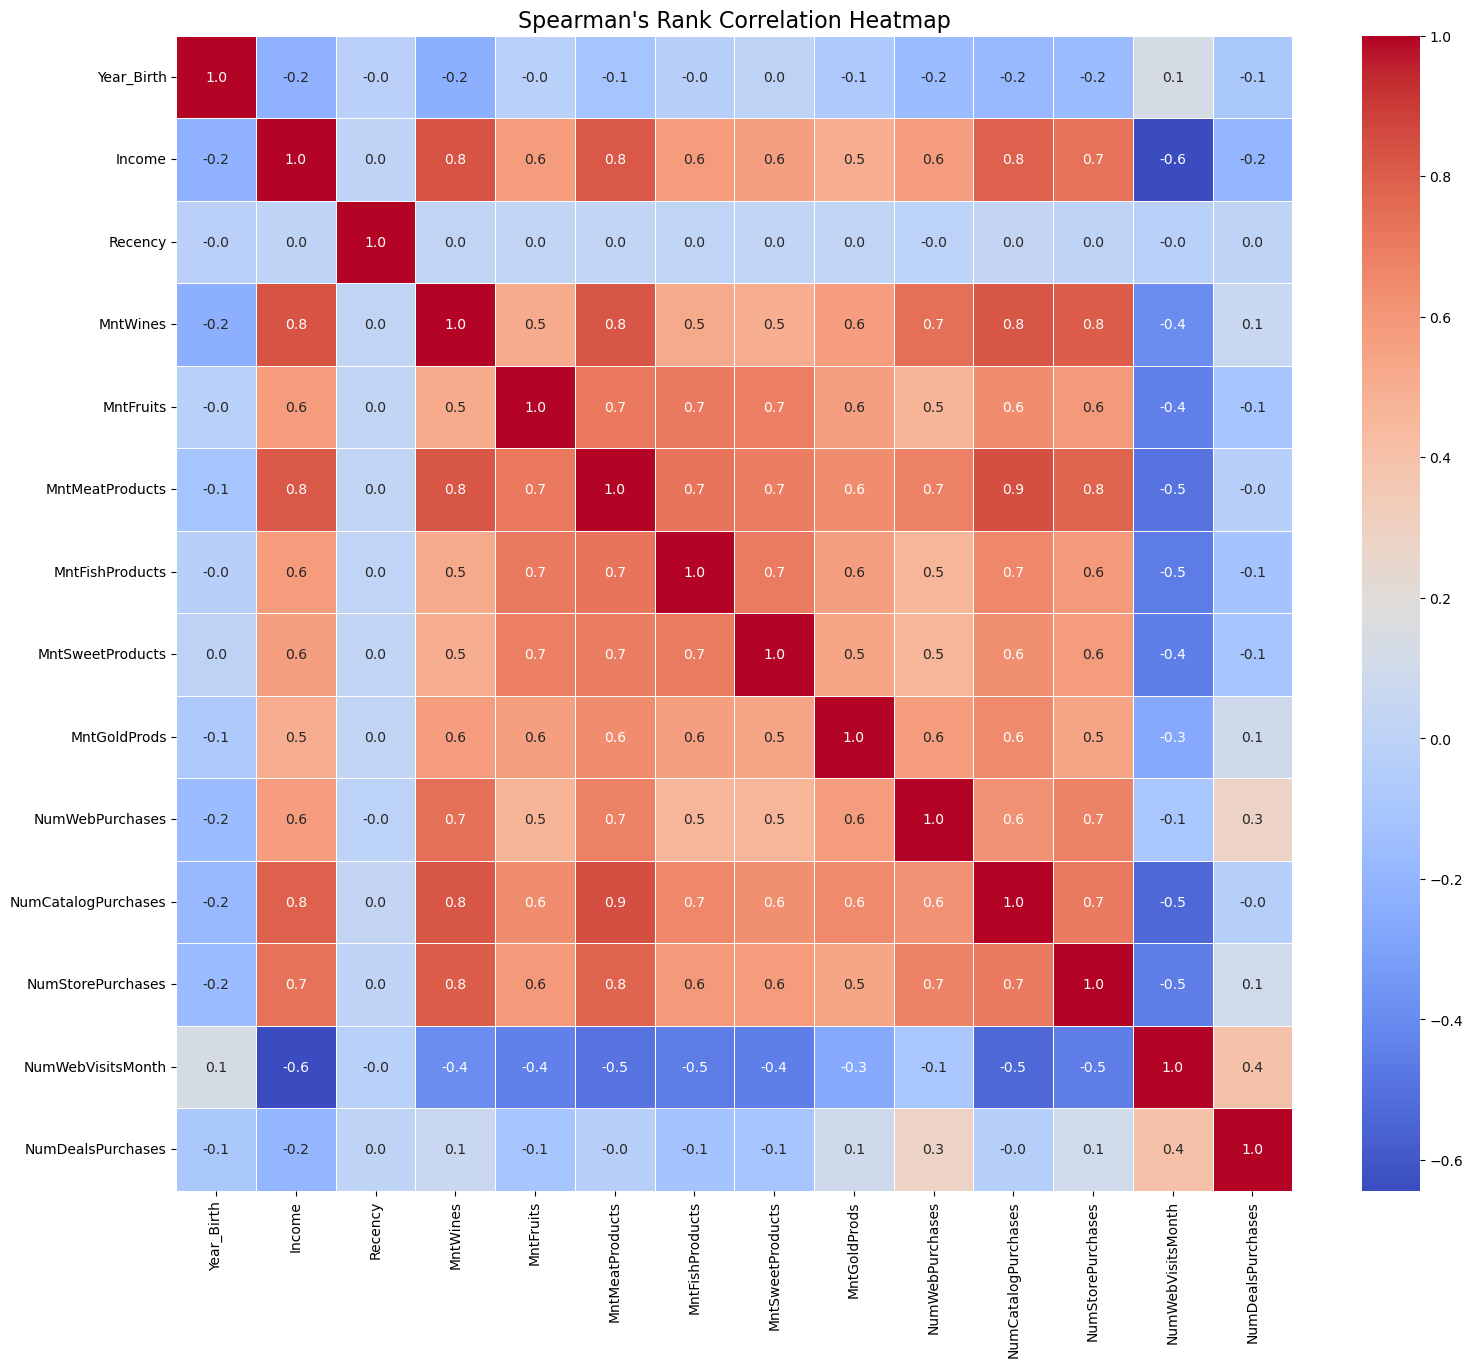


Spearman Correlation between numeric features:

Year_Birth & Income: -0.217
Year_Birth & Recency: -0.021
Year_Birth & MntWines: -0.234
Year_Birth & MntFruits: -0.025
Year_Birth & MntMeatProducts: -0.112
Year_Birth & MntFishProducts: -0.031
Year_Birth & MntSweetProducts: 0.003
Year_Birth & MntGoldProds: -0.077
Year_Birth & NumWebPurchases: -0.164
Year_Birth & NumCatalogPurchases: -0.179
Year_Birth & NumStorePurchases: -0.168
Year_Birth & NumWebVisitsMonth: 0.131
Year_Birth & NumDealsPurchases: -0.087
Income & Recency: 0.008
Income & MntWines: 0.830
Income & MntFruits: 0.582
Income & MntMeatProducts: 0.817
Income & MntFishProducts: 0.577
Income & MntSweetProducts: 0.567
Income & MntGoldProds: 0.506
Income & NumWebPurchases: 0.573
Income & NumCatalogPurchases: 0.792
Income & NumStorePurchases: 0.732
Income & NumWebVisitsMonth: -0.644
Income & NumDealsPurchases: -0.196
Recency & MntWines: 0.019
Recency & MntFruits: 0.025
Recency & MntMeatProducts: 0.028
Recency & MntFishProducts: 0.013
Re

In [17]:
spearman_corr = num_cols.corr(method='spearman')
plt.figure(figsize=(18, 15))

sns.heatmap(spearman_corr, annot=True, fmt=".1f", cmap="coolwarm", cbar=True,
            annot_kws={"size":10}, linewidths=0.5)

plt.title("Spearman's Rank Correlation Heatmap", fontsize=16)
plt.show()

# Print correlations as a list
print("\nSpearman Correlation between numeric features:\n")
for i in range(len(spearman_corr.columns)):
    for j in range(i+1, len(spearman_corr.columns)):
        feature_1 = spearman_corr.columns[i]
        feature_2 = spearman_corr.columns[j]
        corr_value = spearman_corr.iloc[i, j]
        print(f"{feature_1} & {feature_2}: {corr_value:.3f}")

**Key Insights:**

- A strong latent **customer value / engagement dimension** emerges across the dataset.
  Income, total spend across product categories, and purchase counts across channels
  are all highly and positively correlated (ρ ≈ 0.7–0.85).

- Product-level spending features (`Mnt*`) exhibit **high multicollinearity**.
  Customers tend to spend consistently across categories rather than specializing
  in individual product types.

- Purchase activity and website behavior show an inverse relationship.
  High-spending customers make more purchases but have fewer website visits,
  while lower-value customers browse more but convert less.

- `Recency` shows weak monotonic correlation with spending and purchases,
  suggesting it captures temporal behavior rather than customer value.

- Age (`Year_Birth`) has weak but consistent negative correlations with spending
  and purchase frequency, indicating subtle lifecycle effects.

#### Zero Inflation Analysis

In [20]:
# -----------------------------
# Zero Inflation Analysis
# -----------------------------

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

zero_summary = pd.DataFrame({
    'zero_count': (df[numeric_cols] == 0).sum(),
    'zero_pct': ((df[numeric_cols] == 0).mean() * 100)
})

zero_summary = (
    zero_summary
    .sort_values(
        'zero_pct',
        ascending=False
    )
)

zero_summary

,zero_count,zero_pct
Complain,2219,99.062500
AcceptedCmp2,2210,98.660714
AcceptedCmp1,2096,93.571429
AcceptedCmp5,2077,92.723214
AcceptedCmp3,2077,92.723214
AcceptedCmp4,2073,92.544643
Response,1906,85.089286
Kidhome,1293,57.723214
Teenhome,1158,51.696429
NumCatalogPurchases,586,26.160714


**Zero Inflation Analysis**

Zero-inflation analysis was performed to identify features dominated by the absence of behavior. Several campaign-related variables (`AcceptedCmp1–5`, `Response`) and the complaint indicator exhibited extremely high proportions of zero values, reflecting relatively rare customer actions within the dataset. While these features showed limited overall activity, they were retained because campaign responsiveness and customer engagement behavior may provide meaningful segmentation signals despite their sparsity. Spending and purchasing variables generally displayed much lower levels of zero inflation, suggesting they contain richer behavioral information for cluster formation.


#### Categorical Feature Audit

**Cardinality Analysis**

In [24]:
categorical_features = [
    "Education",
    "Marital_Status",
    "Kidhome",
    "Teenhome"
]

for col in categorical_features:

    print("\n" + "="*50)
    print(col)
    print("="*50)

    print(f"Unique Categories: {df[col].nunique()}")

    freq_table = pd.DataFrame({
        "count": df[col].value_counts(),
        "percentage": round(
            df[col].value_counts(normalize=True) * 100,
            2
        )
    })

    display(freq_table)


Education
Unique Categories: 5


,count,percentage
Education,,
Graduation,1127,50.31
PhD,486,21.7
Master,370,16.52
2n Cycle,203,9.06
Basic,54,2.41



Marital_Status
Unique Categories: 8


,count,percentage
Marital_Status,,
Married,864,38.57
Together,580,25.89
Single,480,21.43
Divorced,232,10.36
Widow,77,3.44
Alone,3,0.13
Absurd,2,0.09
YOLO,2,0.09



Kidhome
Unique Categories: 3


,count,percentage
Kidhome,,
0,1293,57.72
1,899,40.13
2,48,2.14



Teenhome
Unique Categories: 3


,count,percentage
Teenhome,,
0,1158,51.70
1,1030,45.98
2,52,2.32


**Category Frequency Analysis**

In [26]:
freq_table = pd.DataFrame({
    "count": df[col].value_counts(),
    "percentage":
    round(
        df[col].value_counts(normalize=True)*100,
        2
    )
})
freq_table

,count,percentage
Teenhome,,
0,1158,51.70
1,1030,45.98
2,52,2.32


**Rare Category Detection**

In [28]:
RARE_THRESHOLD = 5

for col in categorical_features:

    print("\n" + "="*50)
    print(f"Rare Categories - {col}")
    print("="*50)

    rare = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
    )

    rare = rare[rare < RARE_THRESHOLD]

    if len(rare) > 0:
        display(rare)
    else:
        print("No rare categories detected")


Rare Categories - Education


Education
Basic    2.410714
Name: proportion, dtype: Float64


Rare Categories - Marital_Status


Marital_Status
Widow       3.4375
Alone     0.133929
Absurd    0.089286
YOLO      0.089286
Name: proportion, dtype: Float64


Rare Categories - Kidhome


Kidhome
2    2.142857
Name: proportion, dtype: float64


Rare Categories - Teenhome


Teenhome
2    2.321429
Name: proportion, dtype: float64

**Categorical Feature Audit**

The categorical feature audit evaluated cardinality, frequency distributions, and rare-category prevalence across education, marital status, and household composition variables. **Education** was primarily represented by Graduation, PhD, and Master categories, while **Marital_Status** was dominated by Married, Together, and Single customers. Several low-frequency categories were identified, including Basic education and uncommon marital statuses such as Alone, Absurd, and YOLO. Household composition variables (**Kidhome** and **Teenhome**) exhibited low cardinality and were concentrated in the 0 and 1 child groups, with the 2-child categories appearing infrequently. These findings highlighted potential sources of sparsity and provided justification for subsequent category grouping and encoding decisions designed to improve cluster stability and interpretability.

#### Outliers visualization

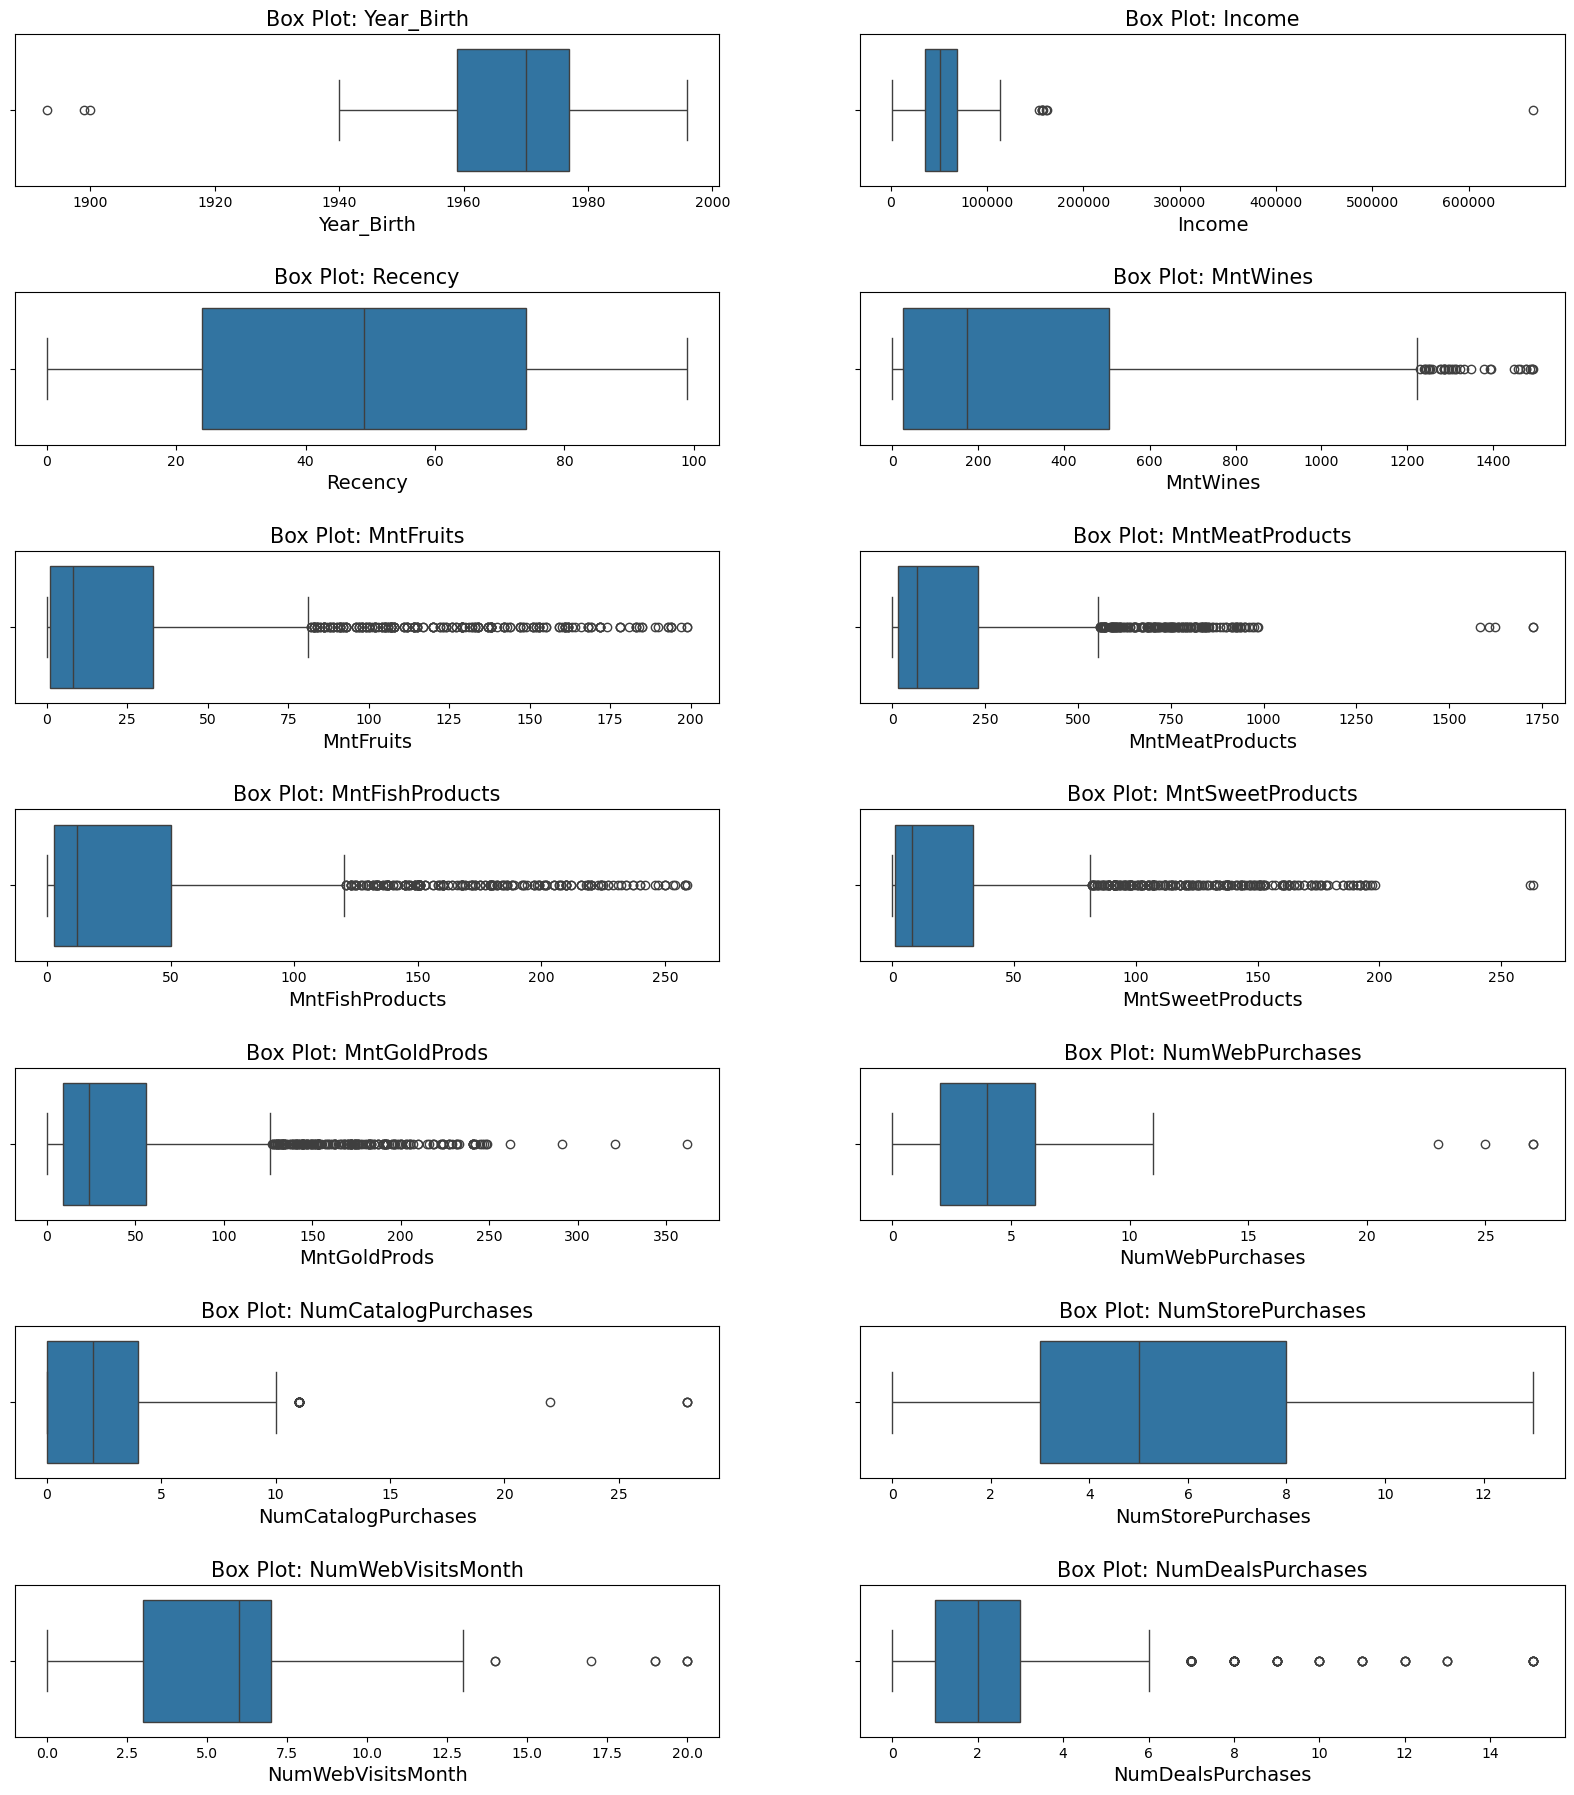

In [31]:
plt.figure(figsize=(20,200))

def outliers_boxplot(df):
    for i, col in enumerate(num_cols):
        if col != 'y': 
            ax = plt.subplot(60, 2, i+1)
            sns.boxplot(data=df, x=col, ax=ax)
            plt.subplots_adjust(hspace = 0.7)
            plt.title('Box Plot: {}'.format(col), fontsize=15)
            plt.xlabel('{}'.format(col), fontsize=14)
        
outliers_boxplot(df)

#### IQR

In [33]:
#Creating a table for outliers change
out_df = pd.DataFrame(columns=['feature', 'outliers_cnt', 'distribution_changed', 'correlation_changed'])
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed


In [34]:
from scipy.stats import ks_2samp, pointbiserialr

target_col = 'Response'
numeric_cols = df.select_dtypes(include=['number']).columns

out_df = pd.DataFrame(columns=['feature', 'outliers_cnt', 'distribution_changed', 'correlation_changed'])

# IQR-based outlier detection
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers_df = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).astype(int)

for col in numeric_cols:
    out = df[col]
    mask = outliers_df[col] == 0
    non_out = df.loc[mask, col]  # Feature values without outliers
    target_non_out = df.loc[mask, target_col]  # Align target values

    # KS test
    dist_change = '+' if ks_2samp(out.dropna(), non_out.dropna())[1] < 0.05 else '-'

    # Correlation change (aligned)
    corr_full, _ = pointbiserialr(df[target_col], df[col].fillna(df[col].median()))
    corr_no_out, _ = pointbiserialr(target_non_out, non_out.fillna(non_out.median()))
    corr_changed = '+' if abs(corr_full - corr_no_out) > 0.05 else '-'

    # Store results
    new_row = pd.DataFrame({
        'feature': [col],
        'outliers_cnt': [outliers_df[col].sum()],
        'distribution_changed': [dist_change],
        'correlation_changed': [corr_changed]
    })

    out_df = pd.concat([out_df, new_row], ignore_index=True)

out_df

C:\Users\Almog\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:5535: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,feature,outliers_cnt,distribution_changed,correlation_changed
0,Year_Birth,3,-,-
1,Income,8,-,-
2,Kidhome,0,-,-
3,Teenhome,0,-,-
4,Recency,0,-,-
5,MntWines,35,-,-
6,MntFruits,227,+,-
7,MntMeatProducts,175,+,+
8,MntFishProducts,223,+,-
9,MntSweetProducts,248,+,-


In [35]:
# Add the 'drop' column based on specified conditions
out_df['drop'] = np.where(
    (out_df['distribution_changed'] == '+') & (out_df['correlation_changed'] == '-'),
    'yes', 'no'
)

# List of features recommended to drop outliers
to_drop = out_df[out_df['drop'] == 'yes']['feature']

# Display the resulting DataFrame with the drop decision
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed,drop
0,Year_Birth,3,-,-,no
1,Income,8,-,-,no
2,Kidhome,0,-,-,no
3,Teenhome,0,-,-,no
4,Recency,0,-,-,no
5,MntWines,35,-,-,no
6,MntFruits,227,+,-,yes
7,MntMeatProducts,175,+,+,no
8,MntFishProducts,223,+,-,yes
9,MntSweetProducts,248,+,-,yes


**Outlier Handling Decision**

Although the IQR method identified a substantial number of outliers in several behavioral and spending-related features, these values were intentionally retained. In the context of customer behavior and marketing response modeling, extreme values often represent legitimate but rare customer segments (e.g., high spenders or highly engaged users) rather than data errors. Removing such observations would risk eliminating meaningful signal and biasing the model toward average behavior. Instead of dropping outliers, we rely on model robustness (particularly for tree-based models) and, where appropriate, feature transformations during later stages of feature engineering. Outliers in the target variable were also preserved by design, as they represent the very outcomes the model is intended to learn.


#### Data Imputation

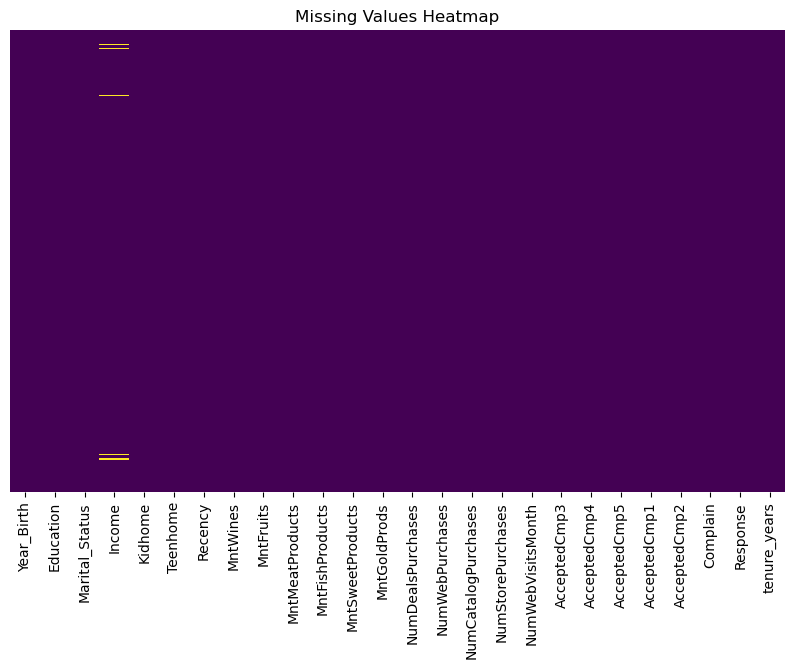

In [38]:
# Check if there are missing values
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")
else:
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
    plt.title("Missing Values Heatmap")
    plt.show()

In [39]:
# Filling 'Income' NaN values - Median income imputation
income_median = df["Income"].median()
df["Income"] = df["Income"].fillna(income_median)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   string 
 2   Marital_Status       2240 non-null   string 
 3   Income               2240 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   MntWines             2240 non-null   int64  
 8   MntFruits            2240 non-null   int64  
 9   MntMeatProducts      2240 non-null   int64  
 10  MntFishProducts      2240 non-null   int64  
 11  MntSweetProducts     2240 non-null   int64  
 12  MntGoldProds         2240 non-null   int64  
 13  NumDealsPurchases    2240 non-null   int64  
 14  NumWebPurchases      2240 non-null   int64  
 15  NumCatalogPurchases  2240 non-null   i

In [40]:
df.to_pickle(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Pickle files\EDA_MC1.pkl")